In [1]:
"""
Downloading fuels treatments which overlap or are within 1km of fire perimeters
Maxwell.Cook@colostate.edu
"""

# imports
import os, sys

# import the __functions.py (custom functions)
sys.path.append(os.getcwd()) # add code folder to system path
from __functions import *  # imports all custom functions

# local data directories
datadir = '/Users/mcc/Library/CloudStorage/Box-Box/MCC/data/'
projdir = os.path.dirname(os.getcwd())
print(projdir)

print("Complete!")

/Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/valuation
Complete!


In [2]:
# load the fire data
mtbs = os.path.join(projdir, 'data/spatial/wf_incidents_2014_2022_mtbs_perims.gpkg')
mtbs = gpd.read_file(mtbs)
print(f"Processing for {len(mtbs)} fires.")
print(f"CRS: {mtbs.crs}")
# clean the dataframe just a bit for processing
mtbs = mtbs[['Event_ID','Incid_Name','Ig_Date','BurnBndAc','geometry']]
mtbs.head()

Processing for 3494 fires.
CRS: EPSG:4326


,Event_ID,Incid_Name,Ig_Date,BurnBndAc,geometry
0,NJ3973407472120220619,MULLICA RIVER FIRE,6/19/22 0:00,13082,"MULTIPOLYGON (((-74.69252 39.68403, -74.6923 3..."
1,NC3565607641720220619,FEREBEE ROAD,6/19/22 0:00,1954,"MULTIPOLYGON (((-76.42425 35.65565, -76.42447 ..."
2,FL2576508042220220329,137 AVE,3/29/22 0:00,857,"MULTIPOLYGON (((-80.43589 25.77237, -80.43507 ..."
3,FL2632608099820220328,INTERCEPTOR,3/28/22 0:00,4143,"MULTIPOLYGON (((-81.08343 26.29129, -81.08347 ..."
4,MS3143909088120220304,HWY 556 - BUDE MS,3/4/22 0:00,663,"MULTIPOLYGON (((-90.87669 31.45572, -90.87648 ..."


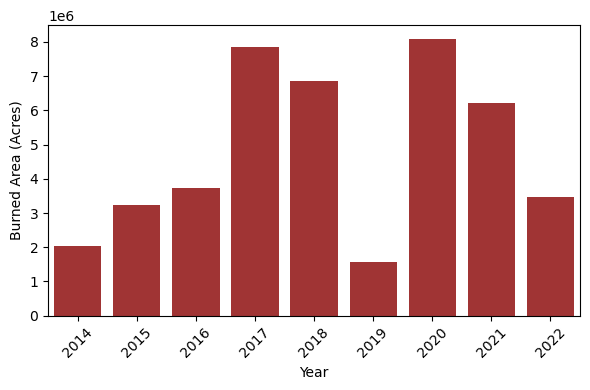

In [3]:
# plot burned area over time
mtbs['Ig_Date'] = pd.to_datetime(mtbs['Ig_Date'], format='%m/%d/%y %H:%M', errors='coerce')
mtbs['Year'] = mtbs['Ig_Date'].dt.year
# Group by year and sum burned area (BurnBndAc)
yearly_burn = mtbs.groupby('Year', as_index=False)['BurnBndAc'].sum()

# plot it
plt.figure(figsize=(6,4))
sns.barplot(data=yearly_burn, x='Year', y='BurnBndAc', color='firebrick')
plt.xlabel('Year')
plt.ylabel('Burned Area (Acres)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# establish connection with the TWIG
twig_url = 'https://gis.reshapewildfire.org/arcgis/rest/services/Hosted/Treatment_Index_and_Intersections/FeatureServer/'
# get the CRS
s_info = requests.get(twig_url + '?f=pjson').json()  # json metadata
srn = s_info['spatialReference']['wkid']  # spatial reference
srn = 'EPSG:' + str(srn)
del s_info

# reproject the fire data to match the TWIG
# fix invalid geometries first
mtbs['geometry'] = mtbs['geometry'].buffer(0)
mtbs = mtbs[~mtbs.is_empty & mtbs.is_valid]
mtbs = mtbs.to_crs(srn) # match TWIG
# buffer fire perimeters by 1km
mtbs['geometry'] = mtbs.geometry.buffer(1000)

# map over fire events
trt_overlap = {} # to store the results
# map over fire perimeters, extract treatments within a distance
for idx, row in tqdm(mtbs.iterrows(), total=mtbs.shape[0], desc='Processing Fires'):
    mtbs_id = row['Event_ID']
    fire_name = row['Incid_Name']
    ig_date = row['Ig_Date']
    # get the fire for later
    perim = mtbs[mtbs['Event_ID'] == mtbs_id][['Event_ID','geometry']]

    try:

        # build the query for dates
        end_date = ig_date.strftime('%Y-%m-%d')
        start_date = (ig_date - pd.DateOffset(years=10)).strftime('%Y-%m-%d')
        qry = (f"(treatment_date BETWEEN DATE '{start_date}' AND DATE '{end_date}' "
               f"OR actual_completion_date BETWEEN DATE '{start_date}' AND DATE '{end_date}')")

        # query the TWIG within bounds and for the correct years
        twig = get_feature_service_gdf(twig_url, geo=row['geometry'], layer=0)
        # intersect with the buffered perimeter
        twig = gpd.sjoin(twig, perim, how="inner", predicate="intersects")

        if twig.empty:
            # print(f"No treatments found within 1km of {fire_name}.")
            trt_overlap[fire_name] = None  # or gpd.GeoDataFrame()
        else:
            # print(f"Found {len(twig)} treatments within 1km of {fire_name}.")
            trt_overlap[fire_name] = twig

    except Exception as e:
        # print(f"Error processing {fire_name}: {e}")
        trt_overlap[fire_name] = None  # safe fallback on error

Processing Fires:   0%|          | 0/3494 [00:00<?, ?it/s]

In [5]:
# tidy the TWIG data into one file
# Filter out None values and add a fire name column to each GeoDataFrame
valid_gdfs = []
for fire_name, gdf in trt_overlap.items():
    if gdf is not None and not gdf.empty:
        gdf = gdf.copy()
        gdf['Fire_Name'] = fire_name
        valid_gdfs.append(gdf)

# Concatenate all into a single GeoDataFrame
if valid_gdfs:
    trts_all = gpd.GeoDataFrame(pd.concat(valid_gdfs, ignore_index=True), crs=valid_gdfs[0].crs)
else:
    trts_all = gpd.GeoDataFrame()  # Empty GeoDataFrame if no overlaps found

# Inspect result
print(f"Total treatments found: {len(trts_all)}")

Total treatments found: 154402


In [6]:
trts_all.head()

,geometry,type,date_source,identifier_database,fund_source,state,SHAPE__Area,unique_id,actual_completion_date,agency,...,Fire_Name,activity,total_cost,cost_per_uom,fund_code,uom,method,equipment,activity_code,error
0,"MULTIPOLYGON (((-8496089.925 4267808.009, -849...",Mastication,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,126344-6325503,1.631750e+12,FWS,...,FEREBEE ROAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"MULTIPOLYGON (((-8496089.925 4267808.009, -849...",Mastication,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,126342-6325503,1.631750e+12,FWS,...,FEREBEE ROAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"MULTIPOLYGON (((-8496089.925 4267808.009, -849...",Mastication,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,126343-6325503,1.631750e+12,FWS,...,FEREBEE ROAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"MULTIPOLYGON (((-8496089.925 4267808.009, -849...",Mowing,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,137998-6325504,1.659312e+12,FWS,...,FEREBEE ROAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"MULTIPOLYGON (((-8496089.925 4267808.009, -849...",Mowing,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,138000-6325504,1.659312e+12,FWS,...,FEREBEE ROAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
trts_all.columns

Index(['geometry', 'type', 'date_source', 'identifier_database', 'fund_source',
       'state', 'SHAPE__Area', 'unique_id', 'actual_completion_date', 'agency',
       'date_current', 'twig_category', 'treatment_date', 'name', 'acres',
       'category', 'SHAPE__Length', 'objectid', 'index_right', 'Event_ID',
       'Fire_Name', 'activity', 'total_cost', 'cost_per_uom', 'fund_code',
       'uom', 'method', 'equipment', 'activity_code', 'error'],
      dtype='object')

In [8]:
# save the treatment data out
out_fp = os.path.join(projdir, 'data/spatial/treatments/twig_treatments_1km.gpkg')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
trts_all.to_file(out_fp)
print(f"Saved to: {out_fp}")

Saved to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/valuation/data/spatial/treatments/twig_treatments_1km.gpkg
